# Predicting wine quality

This [kaggle dataset](https://www.kaggle.com/rajyellow46/wine-quality) is originally found in the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). Similar to the wine dataset that comes with sklearn, this dataset is also about wine but the goal is to predict the quality of the wine as a integer score ranging from 1 to 10. A summary of the dataset is shown below. One thing to notice is that the dataset is quite unbalanced in terms of quality, the feature we want to predict. As we can see that the mean of the column is about 5.8 with a standard deviation of 0.87, which means the majority of the wine sampled have a mediocore quality and only a small percentage of the samples are considered as either good or poor. 

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sn
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.metrics import confusion_matrix
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense

data_df = read_csv('winequalityN.csv')
data_df.describe(include = 'all')
# print(data_df.columns)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,white,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,NaN,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,NaN,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,NaN,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,NaN,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,NaN,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000


### Imputing missing data

 There are missing data in quite a few features including fixed acidity, volatile acidity, residual sugar, chlorides, pH, and sulphates. The percentage of the missing value takes in whole sample size is very small. However, since the dataset is unbalanced, these missing values could potentially have a big impact on the prediction if they happend to correspond to the outlier classes.
 <br> <br>
 In this example I used the mean imputing method to fill in the missing data. The disadvantage of this method is that the bias in the existing data might become stronger, especially like the case here where the sample data is unbalanced. However, I believe using this method here is justifiable according to the [ACM Code of ethics](https://www.acm.org/code-of-ethics) because it still agree with the major principles such as "avoid harm" and "be fair and take action not to discriminate". As this example here is only about predicting wine quality, I think the consequences of mis-prediction is not very serious.

In [2]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy="mean")
featuresWithMissing = ["fixed acidity", "volatile acidity","citric acid", "residual sugar", "chlorides", "pH", "sulphates"]
imputer = imputer.fit(data_df[featuresWithMissing])
data_df[featuresWithMissing] = imputer.transform(data_df[featuresWithMissing]) 
data_df.describe(include = 'all')

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,white,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,NaN,1.295751,0.164548,0.145231,4.757392,0.035031,17.749400,56.521855,0.002999,0.160637,0.148768,1.192712,0.873255
min,NaN,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,NaN,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,NaN,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,NaN,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000


In the following steps we remove outliers in the "residual sugar", "free sulfur dioxide" and "total sulfur dioxide" features. This step is inspired by this Kaggle [post](https://www.kaggle.com/ckoushik2805/winequality-classification-model-95-accuracy#Importing-necessary-packages)

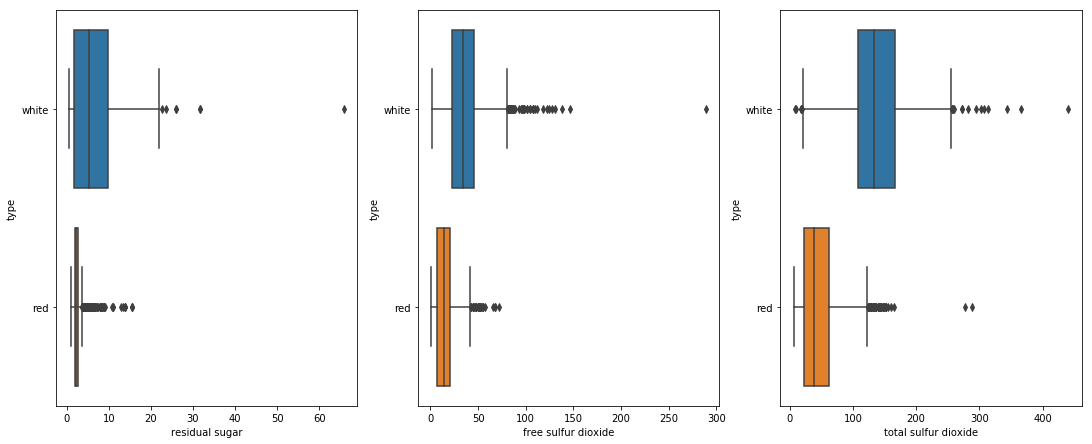

In [3]:
fig, ax =plt.subplots(1,3)
plt.subplots_adjust(right=2.5, top=1.5)
sn.boxplot(data_df['residual sugar'], data_df['type'], ax=ax[0])
sn.boxplot(data_df['free sulfur dioxide'], data_df['type'], ax=ax[1])
sn.boxplot(data_df['total sulfur dioxide'], data_df['type'], ax=ax[2])
plt.show()

In [4]:
#Removing outliers in residual sugar
for i in ['residual sugar','free sulfur dioxide', 'total sulfur dioxide']:
    lower = data_df[i].mean()-3*data_df[i].std()
    upper = data_df[i].mean()+3*data_df[i].std()
    data_df = data_df[(data_df[i]>lower) & (data_df[i]<upper)]

In the following we convert type "white" and "red" into 0 and 1 respectively so that they can be used in the neural network 

In [5]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
enc.fit(data_df[["type"]])
data_df[["type"]] = enc.fit_transform(data_df[["type"]])
data_df.describe(include = 'all')

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000,6430.000000
mean,0.751477,7.220562,0.340231,0.318550,5.364726,0.056117,30.041291,114.909487,0.994669,3.219071,0.531578,10.495914,5.820995
std,0.432190,1.298764,0.164884,0.144877,4.588666,0.035170,16.619088,55.840907,0.002923,0.160486,0.148807,1.192011,0.870076
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,1.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992320,3.110000,0.430000,9.500000,5.000000
50%,1.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994880,3.210000,0.510000,10.300000,6.000000
75%,1.000000,7.700000,0.410000,0.390000,8.000000,0.065000,41.000000,155.000000,0.996927,3.320000,0.600000,11.300000,6.000000
max,1.000000,15.900000,1.580000,1.660000,19.600000,0.611000,83.000000,282.000000,1.003690,4.010000,2.000000,14.900000,9.000000


Now we split the data into training and test set with a 8-2 ratio

In [6]:
from sklearn import model_selection
array = data_df.values
# get number of columns
n = array.shape[1] 
X = array[:,0:n-2]
Y = array[:,n-1]
test_size = 0.2
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,Y,test_size=test_size, random_state=1)

### Deep Neural Network

I wanted to use a softmax layer to predict the different qualities as different categories since we only allow integer values. So I converted the quality, the target, into one hot vectors as shown below

In [7]:
from keras.utils import to_categorical
Y_train_categorical = to_categorical(Y_train,num_classes=10)
Y_test_categorical = to_categorical(Y_test,num_classes=10)

In this experiment I tried training a network with 3 fully connected layer with 20, 30, and 20 neurons each with a softmax layer at the end for prediction. The hyper parameter we tuned here is the number of epoch trained as we expect to see a increasing curve that gets stuck at a certain point, which will be the number of epoch we want to choose to train this network.

In [8]:
scores = []
epochs = range(10, 80, 10)
for epoch in epochs:
    model = tf.keras.models.Sequential()
    # Build the input and the hidden layers
    model.add(tf.keras.layers.Dense(20, activation="relu"))
    model.add(tf.keras.layers.Dense(30, activation="relu"))
    model.add(tf.keras.layers.Dense(20, activation="relu"))
    # Build the output layer
    model.add(tf.keras.layers.Dense(10, activation ="softmax"))
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(x=X_train, y=Y_train_categorical, epochs=epoch) 
    scores.append(model.evaluate(X_test, Y_test_categorical)[1])


Epoch 1/10
161/161 [==============================] - 0s 2ms/step - loss: 1.7866 - accuracy: 0.3820
Epoch 2/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2978 - accuracy: 0.4323
Epoch 3/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2706 - accuracy: 0.4378
Epoch 4/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2531 - accuracy: 0.4479
Epoch 5/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2436 - accuracy: 0.4524
Epoch 6/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2323 - accuracy: 0.4514
Epoch 7/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2314 - accuracy: 0.4444
Epoch 8/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2321 - accuracy: 0.4617
Epoch 9/10
161/161 [==============================] - 0s 2ms/step - loss: 1.2178 - accuracy: 0.4596
Epoch 10/10
41/41 [==============================] - 0s 1ms/step - loss: 1.2325 - accuracy: 0.4471
E

161/161 [==============================] - 0s 2ms/step - loss: 1.2208 - accuracy: 0.4613
Epoch 20/40
161/161 [==============================] - 0s 2ms/step - loss: 1.2149 - accuracy: 0.4749
Epoch 21/40
161/161 [==============================] - 0s 2ms/step - loss: 1.2023 - accuracy: 0.4852
Epoch 22/40
161/161 [==============================] - 0s 2ms/step - loss: 1.2051 - accuracy: 0.4761
Epoch 23/40
161/161 [==============================] - 0s 2ms/step - loss: 1.1975 - accuracy: 0.4813
Epoch 24/40
161/161 [==============================] - 0s 2ms/step - loss: 1.2029 - accuracy: 0.4759
Epoch 25/40
161/161 [==============================] - 0s 2ms/step - loss: 1.2111 - accuracy: 0.4675
Epoch 26/40
161/161 [==============================] - 0s 2ms/step - loss: 1.1878 - accuracy: 0.4868
Epoch 27/40
161/161 [==============================] - 0s 2ms/step - loss: 1.1954 - accuracy: 0.4782
Epoch 28/40
161/161 [==============================] - 0s 2ms/step - loss: 1.1939 - accuracy: 0.4819
Ep

161/161 [==============================] - 0s 2ms/step - loss: 1.2244 - accuracy: 0.4545
Epoch 9/60
161/161 [==============================] - 0s 2ms/step - loss: 1.2199 - accuracy: 0.4576
Epoch 10/60
161/161 [==============================] - 0s 2ms/step - loss: 1.2121 - accuracy: 0.4652
Epoch 11/60
161/161 [==============================] - 0s 2ms/step - loss: 1.2073 - accuracy: 0.4646
Epoch 12/60
161/161 [==============================] - 0s 2ms/step - loss: 1.2025 - accuracy: 0.4633
Epoch 13/60
161/161 [==============================] - 0s 2ms/step - loss: 1.2112 - accuracy: 0.4644
Epoch 14/60
161/161 [==============================] - 0s 2ms/step - loss: 1.1938 - accuracy: 0.4706
Epoch 15/60
161/161 [==============================] - 0s 2ms/step - loss: 1.1861 - accuracy: 0.4769
Epoch 16/60
161/161 [==============================] - 0s 2ms/step - loss: 1.1857 - accuracy: 0.4751
Epoch 17/60
161/161 [==============================] - 0s 2ms/step - loss: 1.1832 - accuracy: 0.4821
Epo

161/161 [==============================] - 0s 2ms/step - loss: 1.2015 - accuracy: 0.4728
Epoch 29/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1928 - accuracy: 0.4790
Epoch 30/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1896 - accuracy: 0.4804
Epoch 31/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1875 - accuracy: 0.4811
Epoch 32/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1914 - accuracy: 0.4811
Epoch 33/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1897 - accuracy: 0.4782
Epoch 34/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1898 - accuracy: 0.4870
Epoch 35/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1778 - accuracy: 0.4922
Epoch 36/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1792 - accuracy: 0.4852
Epoch 37/70
161/161 [==============================] - 0s 2ms/step - loss: 1.1781 - accuracy: 0.4907
Ep

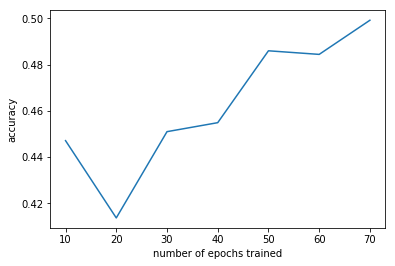

In [18]:
plt.plot(epochs, scores, marker=None)
plt.xlabel('number of epochs trained')
plt.ylabel('accuracy')
plt.show()

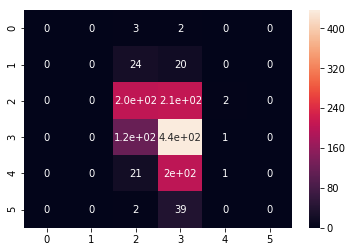

In [19]:
Y_pred = model.predict(X_test)
Y_pred = np.argmax(Y_pred, axis=1)
randomForest_confusion_matrix = confusion_matrix(Y_test, Y_pred)
sn.heatmap(randomForest_confusion_matrix, annot=True)

### Random Forest

Here we try random forest as a non-DNN method for this task. The hyper parameter we are tuning here is the number of trees used.

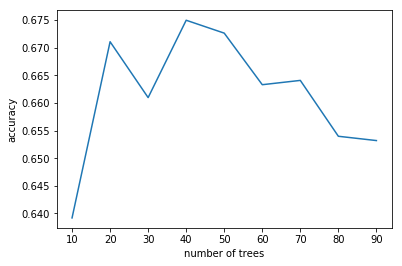

In [20]:
from sklearn.ensemble import RandomForestClassifier
scores = []
n_trees = range(10, 100, 10)
for n in n_trees:
    rfc=RandomForestClassifier(n_estimators=n)
    rfc.fit(X_train,Y_train)
    scores.append(rfc.score(X_test, Y_test))

plt.plot(n_trees, scores, marker=None)
plt.xlabel('number of trees')
plt.ylabel('accuracy')

plt.show()

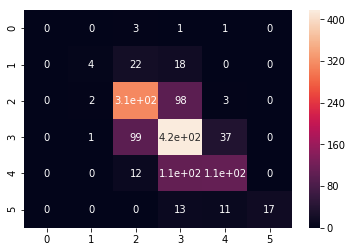

In [22]:
rfc=RandomForestClassifier(n_estimators=40)
rfc.fit(X_train,Y_train)
Y_pred = rfc.predict(X_test)
randomForest_confusion_matrix = confusion_matrix(Y_test, Y_pred)
sn.heatmap(randomForest_confusion_matrix, annot=True)